# Regression - Technical Modification

- Author: Tulsi
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: body_mass_g

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the penguins dataset.
We choose to predict the target `body_mass_g`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

Customize the overview in your copy to reflect your dataset and choices.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number** - mass, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If a straight line fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the line is
  the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [13]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04 Phase 4", level="DEBUG")
log_header(LOG, "M04 Phase 4")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-23 22:21:51 | INFO | M04 Phase 4 | === RUN START ===
2026-07-23 22:21:51 | INFO | M04 Phase 4 | project=M04 Phase 4
2026-07-23 22:21:51 | INFO | M04 Phase 4 | repo_dir=ml-04-regression
2026-07-23 22:21:51 | INFO | M04 Phase 4 | python=3.14.2
2026-07-23 22:21:51 | INFO | M04 Phase 4 | os=Windows 11
2026-07-23 22:21:51 | INFO | M04 Phase 4 | shell=powershell
2026-07-23 22:21:51 | INFO | M04 Phase 4 | cwd=notebooks
2026-07-23 22:21:51 | INFO | M04 Phase 4 | github_actions=False
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Confirming installation:
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   python:       3.14.2
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   pandas:       3.0.3
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   numpy:        2.5.1
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   scikit-learn: 1.9.0
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   seaborn:      0.13.2
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [14]:
# === Section 2. Load and Prepare the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")


# CUSTOM: ANALYST CHOICE - two numeric features (x) and one numeric target (y).
# Flipper length fits well alone; does adding bill length improve the fit?
FEATURE_COLS: Final[list[str]] = ["flipper_length_mm", "bill_length_mm"]
TARGET_COL: Final[str] = "body_mass_g"

TARGET_LABEL: Final[str] = "Body mass (g)"

df_model: pd.DataFrame = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
LOG.info(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

2026-07-23 22:21:51 | INFO | M04 Phase 4 | Loading dataset: penguins
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Loaded: 344 rows (instances), 7 columns
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Original rows: 344  Model rows: 342


## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [15]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, features) and y as shape (n,).

A list of column names gives a DataFrame (2-D);
a single name gives a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_model[FEATURE_COLS].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_model[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"X shape: {X.shape}  (rows, features)")
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-23 22:21:51 | INFO | M04 Phase 4 | X shape: (342, 2)  (rows, features)
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Train instances: 273
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Test instances: 69


## Section 4. Fit a Linear Model

In [16]:
# === Section 4. Fit a Linear Model ===


"""
Fit y = c1 * x1 + c2 * x2 + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (one coefficient per feature) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the coefficients and intercept)
model.fit(X_train, y_train)

# retrieve the results (coefficients and intercept) and log them

coefficients: list[float] = [float(c) for c in model.coef_]
intercept: float = float(model.intercept_)

LOG.info(f"Fitted model for {TARGET_COL}:")
for name, c in zip(FEATURE_COLS, coefficients, strict=True):
    LOG.info(f"  {c:.6g} * {name}")
LOG.info(f"  intercept: {intercept:.6g}")

# Build the equation from the coefficient list so it works for any feature count.
equation: str = " + ".join(
    f"{c:.6g} * {name}" for name, c in zip(FEATURE_COLS, coefficients, strict=True)
)
LOG.info(f"Equation: {TARGET_COL} = {equation} + {intercept:.6g}")

2026-07-23 22:21:51 | INFO | M04 Phase 4 | Fitting a linear regression (scikit-learn)
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Fitted model for body_mass_g:
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   47.5233 * flipper_length_mm
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   5.07302 * bill_length_mm
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   intercept: -5574.38
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Equation: body_mass_g = 47.5233 * flipper_length_mm + 5.07302 * bill_length_mm + -5574.38


## Section 5. Evaluate the Model Fit

2026-07-23 22:21:51 | INFO | M04 Phase 4 | Fit numbers on the TEST set (for you to interpret):
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   R-squared: 0.7838
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   RMSE:      379.113  (in units of Body mass (g))


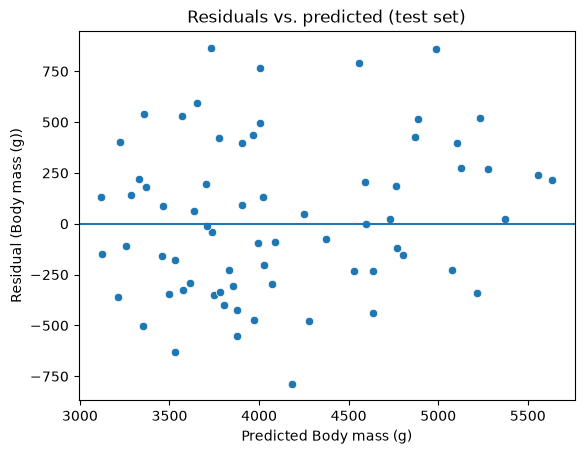

In [17]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the model is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_LABEL})")

# Residual plot: random scatter around 0 means the linear model fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted (test set)")

# show the plot
plt.show()

In [18]:
# === Section 5b. Compare Feature Cases ===

"""Fit the same model on different feature sets and compare on the test set.

WHY: A feature earns its place only if it improves performance on new data.
"""

cases: dict[str, list[str]] = {
    "Case 1: flipper only": ["flipper_length_mm"],
    "Case 2: bill only": ["bill_length_mm"],
    "Case 3: both features": FEATURE_COLS,
}

LOG.info("Feature case comparison (test set):")
for case_label, case_cols in cases.items():
    X_case: np.ndarray = df_model[case_cols].to_numpy()
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        X_case, y, test_size=0.2, random_state=RANDOM_STATE
    )
    case_model = LinearRegression().fit(Xc_train, yc_train)
    case_r2: float = float(case_model.score(Xc_test, yc_test))
    case_rmse: float = float(
        np.sqrt(np.mean((yc_test - case_model.predict(Xc_test)) ** 2))
    )
    LOG.info(f"  {case_label:24} R-squared: {case_r2:.4f}  RMSE: {case_rmse:.3f}")

2026-07-23 22:21:51 | INFO | M04 Phase 4 | Feature case comparison (test set):
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   Case 1: flipper only     R-squared: 0.7820  RMSE: 380.695
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   Case 2: bill only        R-squared: 0.3662  RMSE: 649.168
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   Case 3: both features    R-squared: 0.7838  RMSE: 379.113


### Interpretation

custom

## Section 6. Detect Over- and Under-Fitting

Fit polynomials of increasing **degree** 
(degree 1 is the straight line) and plot
train vs. test RMSE. 

Underfitting shows as both errors high; 
overfitting shows as train RMSE falling while test RMSE rises. 

The best degree is where **test error is lowest** 
and the train/test gap is small.

The analyst decides which degree that is.

2026-07-23 22:21:51 | INFO | M04 Phase 4 |   degree=1  terms= 2  train RMSE=395.911  test RMSE=379.113
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   degree=2  terms= 5  train RMSE=370.582  test RMSE=376.543
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   degree=3  terms= 9  train RMSE=364.199  test RMSE=370.779
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   degree=4  terms=14  train RMSE=362.655  test RMSE=365.778
2026-07-23 22:21:51 | INFO | M04 Phase 4 |   degree=5  terms=20  train RMSE=363.488  test RMSE=365.441


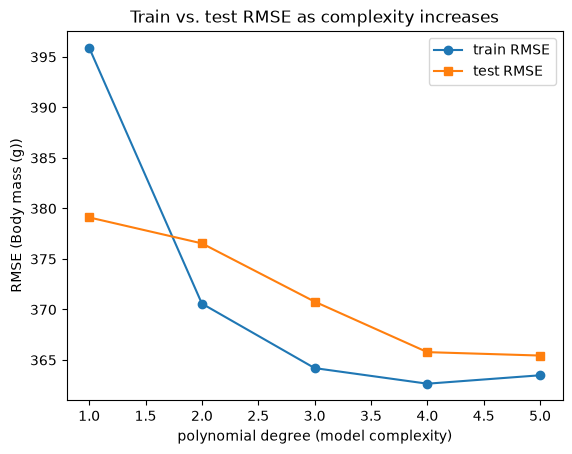

In [19]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Show train vs. test RMSE as model complexity increases.

WHY: Error is not a fixed property of "the model"; it moves with complexity.
Watching train and test diverge is how you detect over- and under-fitting and
pick complexity on purpose.

PolynomialFeatures expands the inputs to include powers and the products
between features, so this works with any number of features.
"""

# CUSTOM: ANALYST CHOICE
# With two features the term count grows quickly, so sweep a shorter range.
MAX_SWEEP: Final[int] = 5

degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly: np.ndarray = poly.fit_transform(X_train)
    X_test_poly: np.ndarray = poly.transform(X_test)

    poly_model = LinearRegression().fit(X_train_poly, y_train)

    train_rmse.append(
        float(np.sqrt(np.mean((y_train - poly_model.predict(X_train_poly)) ** 2)))
    )
    test_rmse.append(
        float(np.sqrt(np.mean((y_test - poly_model.predict(X_test_poly)) ** 2)))
    )
    LOG.info(
        f"  degree={degree}  terms={X_train_poly.shape[1]:2d}  "
        f"train RMSE={train_rmse[-1]:.3f}  test RMSE={test_rmse[-1]:.3f}"
    )

# start a new figure
plt.figure()

# Plot the train and test RMSE against the polynomial degree
# to visualize overfitting and underfitting.
plt.plot(degrees, train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="test RMSE")

# Label the axes and add a title
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel(f"RMSE ({TARGET_LABEL})")
plt.title("Train vs. test RMSE as complexity increases")

# Add a legend
plt.legend()

# Show the plot
plt.show()

### Interpretation

If you see: 

- Both errors high at low degree = underfitting.
- Train RMSE falling while test RMSE rises = overfitting.

Pick a degree and defend it.

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [20]:
# === Python Summary ===


"""Record what was fit and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(f"Features: {', '.join(FEATURE_COLS)}  ->  Target: {TARGET_COL}  (regression)")
LOG.info(f"Equation: {TARGET_COL} = {equation} + {intercept:.6g}")
LOG.info(f"Test R-squared: {r_squared:.4f}   Test RMSE: {rmse:.3f}")
LOG.info("========================")

2026-07-23 22:21:51 | INFO | M04 Phase 4 | ========================
2026-07-23 22:21:51 | INFO | M04 Phase 4 | SUMMARY
2026-07-23 22:21:51 | INFO | M04 Phase 4 | ========================
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Dataset:  penguins
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Features: flipper_length_mm, bill_length_mm  ->  Target: body_mass_g  (regression)
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Equation: body_mass_g = 47.5233 * flipper_length_mm + 5.07302 * bill_length_mm + -5574.38
2026-07-23 22:21:51 | INFO | M04 Phase 4 | Test R-squared: 0.7838   Test RMSE: 379.113
2026-07-23 22:21:51 | INFO | M04 Phase 4 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

YOUR JUDGMENT (include a summary in docs/index.md also):

- Is a straight line a fair description? What did the residuals show?
- What is the RMSE in real units, and is that accurate enough?
- What degree did you choose, and why?

I might answer: 

Test RMSE is lowest at degree 1 (380.695) and rises from degree 2 onward. 
Train RMSE keeps falling, but test never improves - it's already overfitting at degree 2.

The RankWarning at degree 10 confirms it: 
the polynomial is becoming numerically unstable at high degrees, 
which is another sign we're well past the useful range.

When test RMSE is lowest at degree 1 and adding complexity only makes test worse, 
the simplest model wins. 
A straight line fits this data better than any curve.
That is also supported by the residuals not showing any kind of a funnel or curve.

There appears to be a linear relationship (degree = 1) between 
Feature: flipper_length_mm and Target: body_mass_g.

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.
